In [63]:
import os
import pandas as pd
import numpy as np

os.makedirs("stroke_raw", exist_ok=True)

n_samples = 500
np.random.seed(42)

data = {
    "id": range(1, n_samples + 1),
    "gender": np.random.choice(["Male", "Female"], n_samples),
    "age": np.random.randint(20, 80, n_samples),
    "hypertension": np.random.choice([0, 1], n_samples, p=[0.9, 0.1]),
    "heart_disease": np.random.choice([0, 1], n_samples, p=[0.85, 0.15]),
    "ever_married": np.random.choice(["Yes", "No"], n_samples, p=[0.85, 0.15]),
    "work_type": np.random.choice(["Private", "Govt_job", "Never_worked", "Self-employed"], n_samples),
    "Residence_type": np.random.choice(["Urban", "Rural"], n_samples),
    "avg_glucose_level": np.random.uniform(60, 200, n_samples),
    "bmi": np.random.uniform(15, 45, n_samples),
    "smoking_status": np.random.choice(["smokes", "formerly smokes", "never smokes"], n_samples, p=[0.3, 0.2, 0.5]),
    "stroke": np.random.choice([0, 1], n_samples, p=[0.92, 0.08])
}

df = pd.DataFrame(data)
output_path = "stroke_raw/healthcare-dataset-stroke-data.csv"
df.to_csv(output_path, index=False)

print("Dataset stroke berhasil dibuat dan disimpan di:", output_path)
print("Shape:", df.shape)
print(df.head())

Dataset stroke berhasil dibuat dan disimpan di: stroke_raw/healthcare-dataset-stroke-data.csv
Shape: (500, 12)
   id  gender  age  hypertension  heart_disease ever_married      work_type  \
0   1    Male   40             1              1          Yes   Never_worked   
1   2  Female   51             0              1          Yes        Private   
2   3    Male   42             0              1          Yes       Govt_job   
3   4    Male   52             0              0          Yes       Govt_job   
4   5    Male   22             0              1          Yes  Self-employed   

  Residence_type  avg_glucose_level        bmi smoking_status  stroke  
0          Urban         101.915382  35.563316         smokes       0  
1          Urban         110.220174  24.973685         smokes       0  
2          Rural         172.621209  16.697570         smokes       0  
3          Rural          99.026382  26.217631         smokes       0  
4          Rural          89.498695  43.333457   never

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

raw_path = "stroke_raw/healthcare-dataset-stroke-data.csv"
df = pd.read_csv(raw_path)

print("Shape dataset:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape dataset: (500, 12)

First 5 rows:


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1,Male,40,1,1,Yes,Never_worked,Urban,101.915382,35.563316,smokes,0
1,2,Female,51,0,1,Yes,Private,Urban,110.220174,24.973685,smokes,0
2,3,Male,42,0,1,Yes,Govt_job,Rural,172.621209,16.697570,smokes,0
3,4,Male,52,0,0,Yes,Govt_job,Rural,99.026382,26.217631,smokes,0
4,5,Male,22,0,1,Yes,Self-employed,Rural,89.498695,43.333457,never smokes,0


In [65]:
print("Informasi kolom:")
df.info()

print("\nJenis data per kolom:")
df.dtypes

Informasi kolom:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 500 non-null    int64  
 1   gender             500 non-null    object 
 2   age                500 non-null    int64  
 3   hypertension       500 non-null    int64  
 4   heart_disease      500 non-null    int64  
 5   ever_married       500 non-null    object 
 6   work_type          500 non-null    object 
 7   Residence_type     500 non-null    object 
 8   avg_glucose_level  500 non-null    float64
 9   bmi                500 non-null    float64
 10  smoking_status     500 non-null    object 
 11  stroke             500 non-null    int64  
dtypes: float64(2), int64(5), object(5)
memory usage: 47.0+ KB

Jenis data per kolom:


,0
id,int64
gender,object
age,int64
hypertension,int64
heart_disease,int64
ever_married,object
work_type,object
Residence_type,object
avg_glucose_level,float64
bmi,float64


In [66]:
print("Missing values per kolom:")
df.isna().sum()

print("\n% Missing value per kolom:")
missing_pct = df.isna().sum() / len(df) * 100
missing_pct

Missing values per kolom:

% Missing value per kolom:


,0
id,0.0
gender,0.0
age,0.0
hypertension,0.0
heart_disease,0.0
ever_married,0.0
work_type,0.0
Residence_type,0.0
avg_glucose_level,0.0
bmi,0.0


In [67]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,250.500000,50.428000,0.090000,0.178000,130.106741,29.987276,0.074000
std,144.481833,17.223534,0.286468,0.382896,41.126921,8.619010,0.262033
min,1.000000,20.000000,0.000000,0.000000,60.001629,15.059764,0.000000
25%,125.750000,36.000000,0.000000,0.000000,96.955919,22.410237,0.000000
50%,250.500000,50.500000,0.000000,0.000000,129.950777,30.550636,0.000000
75%,375.250000,66.000000,0.000000,0.000000,166.703104,37.126224,0.000000
max,500.000000,79.000000,1.000000,1.000000,199.694920,44.966778,1.000000


/tmp/ipykernel_8978/2325925064.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="stroke", data=df, palette="viridis")


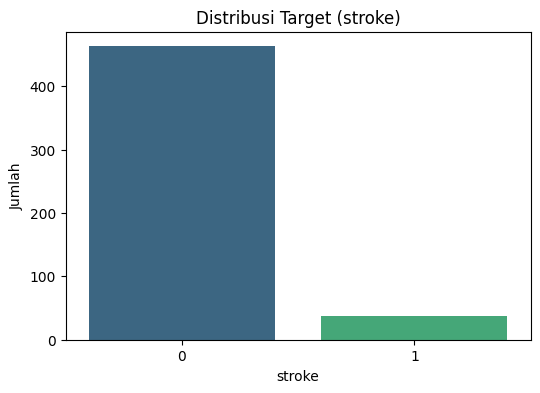

In [68]:
plt.figure(figsize=(6, 4))
sns.countplot(x="stroke", data=df, palette="viridis")
plt.title("Distribusi Target (stroke)")
plt.xlabel("stroke")
plt.ylabel("Jumlah")
plt.show()

/tmp/ipykernel_8978/2692975618.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="stroke", y=col, data=df, palette="viridis")
/tmp/ipykernel_8978/2692975618.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="stroke", y=col, data=df, palette="viridis")
/tmp/ipykernel_8978/2692975618.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="stroke", y=col, data=df, palette="viridis")


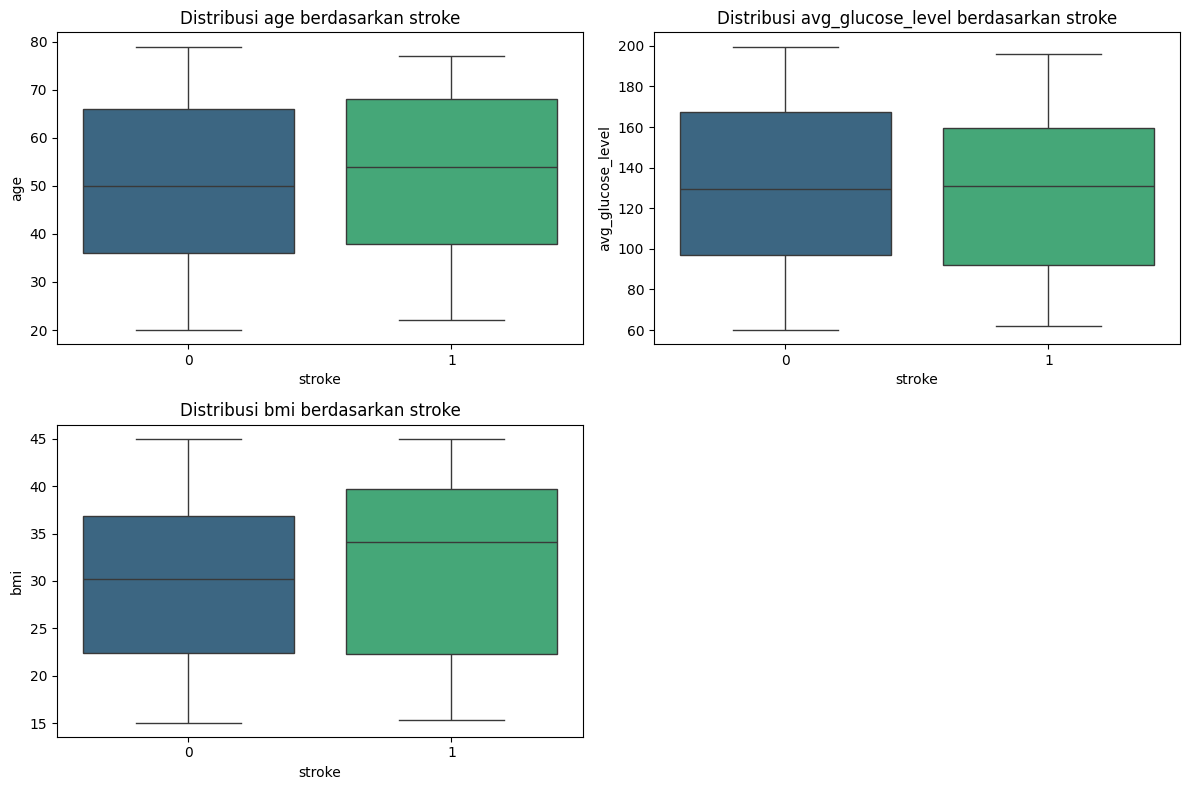

In [69]:
numerik = ["age", "avg_glucose_level", "bmi"]

plt.figure(figsize=(12, 8))
for i, col in enumerate(numerik, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x="stroke", y=col, data=df, palette="viridis")
    plt.title(f"Distribusi {col} berdasarkan stroke")

plt.tight_layout()
plt.show()

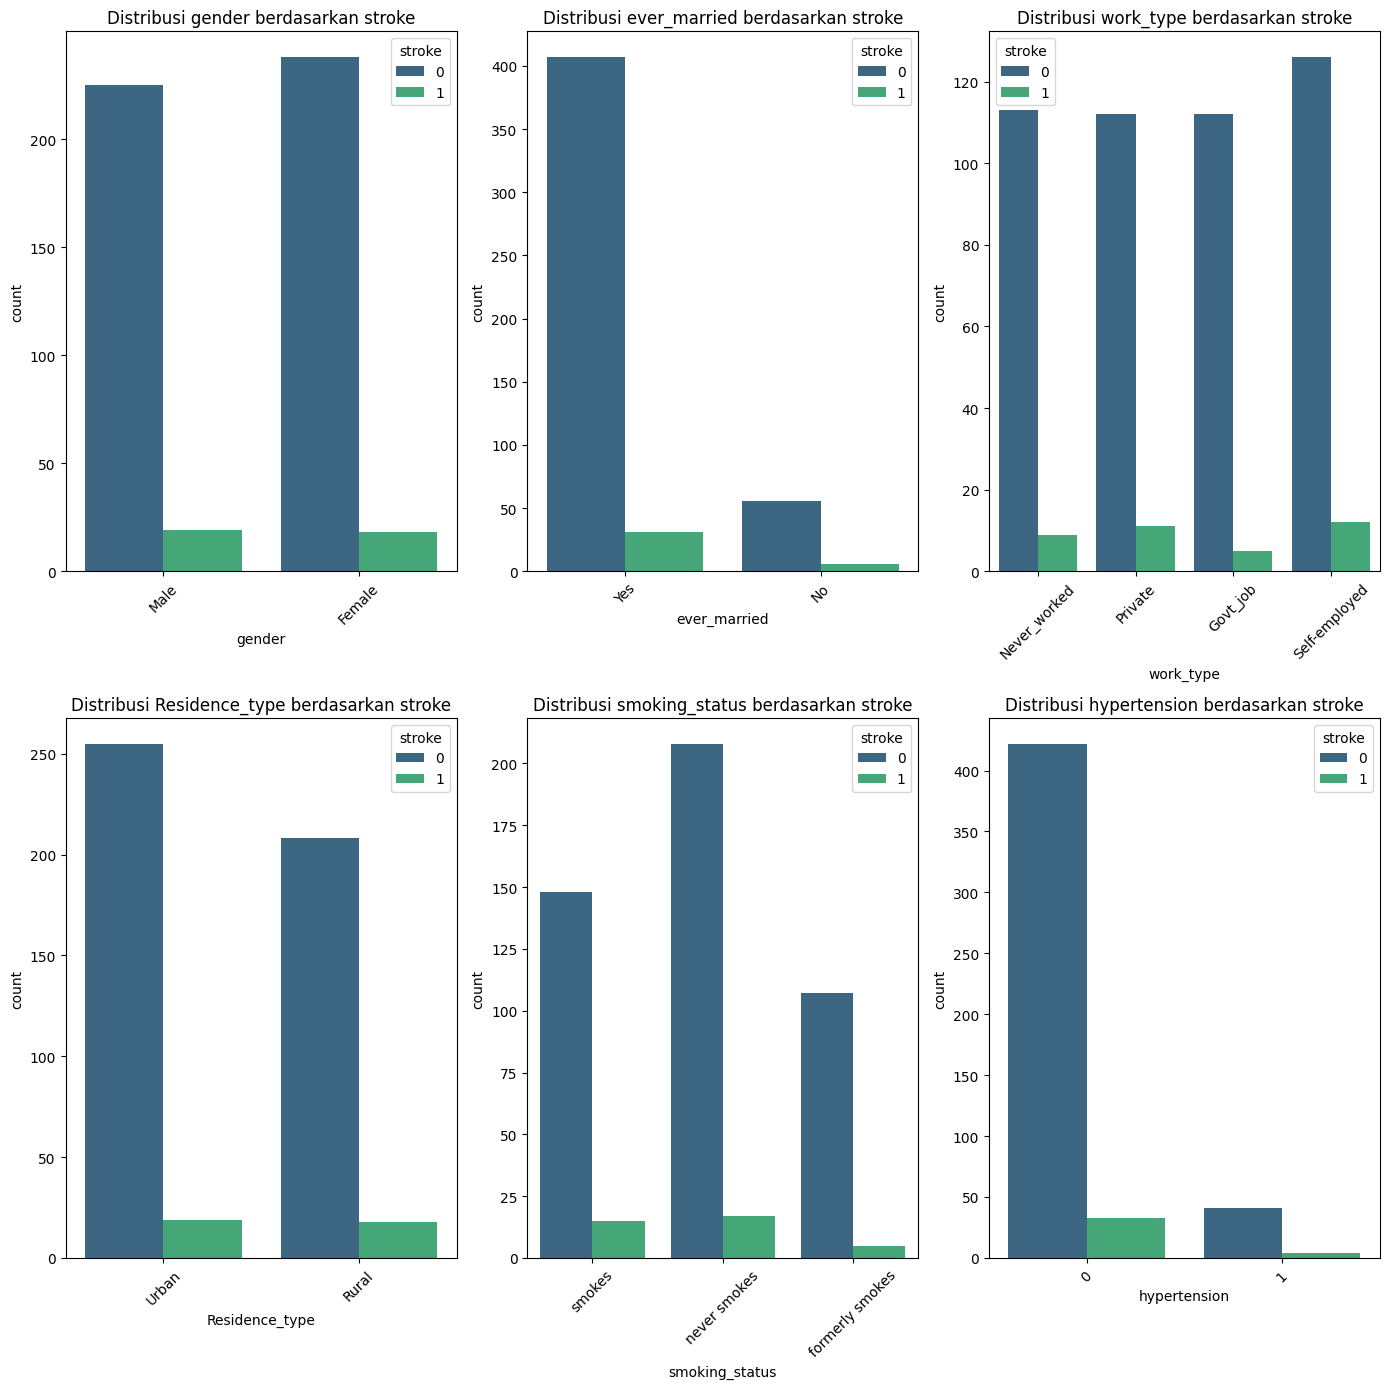

In [71]:
kategorik = ["gender", "ever_married", "work_type", "Residence_type", "smoking_status", "hypertension", "heart_disease"]

plt.figure(figsize=(14, 14))
for i, col in enumerate(kategorik[:6], 1):
    plt.subplot(2, 3, i)
    sns.countplot(x=col, hue="stroke", data=df, palette="viridis")
    plt.title(f"Distribusi {col} berdasarkan stroke")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [72]:
df_prep = df.copy()

In [73]:
print("Missing values sebelum preprocessing:")
df_prep.isna().sum()

if "bmi" in df_prep.columns and df_prep["bmi"].isna().sum() > 0:
    df_prep["bmi"].fillna(df_prep["bmi"].mean(), inplace=True)
    print("Missing value bmi diimpute dengan mean.")

print("\nMissing values setelah preprocessing:")
df_prep.isna().sum()

Missing values sebelum preprocessing:

Missing values setelah preprocessing:


,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,0


In [74]:
if "id" in df_prep.columns:
    df_prep = df_prep.drop(columns=["id"])
    print("Kolom 'id' sudah dihapus.")

Kolom 'id' sudah dihapus.


In [75]:
kolom_kategorikal = df_prep.select_dtypes(include=["object"]).columns.tolist()
print("Kolom kategorikal:", kolom_kategorikal)

le = {}
for col in kolom_kategorikal:
    le[col] = LabelEncoder()
    df_prep[col] = le[col].fit_transform(df_prep[col].astype(str))

print("\nKolom setelah encoding:")
df_prep.head()

Kolom kategorikal: ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

Kolom setelah encoding:


,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1,40,1,1,1,1,1,101.915382,35.563316,2,0
1,0,51,0,1,1,2,1,110.220174,24.973685,2,0
2,1,42,0,1,1,0,0,172.621209,16.697570,2,0
3,1,52,0,0,1,0,0,99.026382,26.217631,2,0
4,1,22,0,1,1,3,0,89.498695,43.333457,1,0


In [76]:
X = df_prep.drop(columns=["stroke"])
y = df_prep["stroke"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Shape X_train:", X_train.shape)
print("Shape X_test:", X_test.shape)
print("Shape y_train:", y_train.shape)
print("Shape y_test:", y_test.shape)

Shape X_train: (400, 10)
Shape X_test: (100, 10)
Shape y_train: (400,)
Shape y_test: (100,)


In [77]:
skaler = StandardScaler()
X_train_scaled = skaler.fit_transform(X_train)
X_test_scaled = skaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print("X_train scaled:")
X_train_scaled.head()

X_train scaled:


,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status
0,1.030464,-0.490295,-0.309662,2.209605,-2.615939,-1.376758,0.886405,0.302837,0.723784,-1.514140
1,-0.970437,0.500200,-0.309662,-0.452570,0.382272,1.287935,0.886405,-0.613892,-0.988746,1.207909
2,-0.970437,1.315903,-0.309662,-0.452570,0.382272,-1.376758,-1.128152,0.555635,1.742505,1.207909
3,1.030464,-1.539056,-0.309662,2.209605,0.382272,0.399704,0.886405,-0.585897,1.008144,1.207909
4,1.030464,0.441936,-0.309662,-0.452570,0.382272,0.399704,0.886405,-1.457090,0.414698,-0.153115


In [78]:
df_preprocessed = pd.concat([X_train_scaled, y_train], axis=1)

import os
os.makedirs("stroke_preprocessing", exist_ok=True)

output_path = "stroke_preprocessing/stroke_preprocessed.csv"
df_preprocessed.to_csv(output_path, index=False)

print("Dataset preprocessed disimpan di:", output_path)

Dataset preprocessed disimpan di: stroke_preprocessing/stroke_preprocessed.csv
